In [96]:
!pip install pandas numpy statsmodels matplotlib prophet seaborn xgboost scikit-learn

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 6.4 MB/s eta 0:00:08
   -- ------------------------------------- 3.1/48.9 MB 8.9 MB/s eta 0:00:06
   ---- ----------------------------------- 5.2/48.9 MB 9.2 MB/s eta 0:00:05
   ------ --------------------------------- 8.1/48.9 MB 10.5 MB/s eta 0:00:04
   -------- ------------------------------- 10.7/48.9 MB 10.7 MB/s eta 0:00:04
   ---------- ----------------------------- 13.4/48.9 MB 10.9 MB/s eta 0:00:04
   ------------- -------------------------- 16.0/48.9 MB 11.1 MB/s eta 0:00:03
   --------------- ------------------------ 18.6/48.9 MB 11.2 MB/s eta 0:00:03
   ----------------- ---------------------- 21.0/48.9 MB 11.2 MB/s eta 0:00:03
   ------------------- -------------------- 23.3/48.9 MB 11.3 MB/s eta 0:00:03
   --------------------- ------------------ 26.0/48.9 MB 11.3 MB/s eta 0:00:03
   ----------------------- ---------------- 28.6/48.9 MB 11.4 MB/s e

In [98]:
import pandas as pd
import numpy as np
import warnings
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from itertools import product
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [95]:
sns.set_theme(style = "whitegrid", rc = { "axes.facecolor": "f8f9fa" })
plt.rcParams['font.family'] = 'sans-serif'
warnings.filterwarnings('ignore')

In [6]:
xlsx_file = pd.ExcelFile("Інформація щодо розміщення ОВДП (2016-2026 роках) (1 шляхом продажу ОВДП на аукціонах з їх розміщення та або обміну).xlsx")

In [7]:
df = pd.read_excel(xlsx_file, sheet_name = xlsx_file.sheet_names[0], skiprows = [1])
df.head()

,Період,"Розміщення на \nпервинному ринку ОВДП, \nномінованих у гривні \n(сума, млн. грн.)","Розміщення на \nпервинному ринку ОВДП, \nномінованих у гривні \n(ср/зв доходність,%)","Розміщення на \nпервинному ринку ОВДП,\nномінованих у гривні: \nЗ них: Кошти залучені \nдо бюджету \n(сума, млн. грн.)","Розміщення на \nпервинному ринку ОВДП,\nномінованих у гривні: \nЗ них: Кошти залучені \nдо бюджету \n(ср/зв доходність,%)","Розміщення на \nпервинному ринку ОВДП,\nномінованих у гривні: З них,\n у тому числі за терміном обігу:\n до 1 року\n(сума, млн. грн.)","Розміщення на \nпервинному ринку ОВДП,\nномінованих у гривні: З них, \nу тому числі за терміном\n обігу: до 1 року\n(ср/зв доходність,%)","Розміщення на \nпервинному ринку ОВДП,\nномінованих у гривні: З них, у тому числі за \nтерміном обігу: від 1 до 3 років (сума, млн. грн.)","Розміщення на \nпервинному ринку ОВДП,\nномінованих у гривні: З них, у тому числі за терміном обігу: від 1 до 3 років \n(ср/зв доходність,%)","Розміщення на \nпервинному ринку ОВДП,\nномінованих у гривні:\n З них, у тому числі за терміном\n обігу: від 3 до 5 років\n(сума, млн. грн.)",...,"Розміщення на \nпервинному ринку ОВДП, \nномінованих у іноземній \nвалюті (євро)\n(сума, млн.євро)","Розміщення на первинному\n ринку ОВДП, номінованих у\n іноземній валюті (євро)\n(ср/зв доходність,%)","Розміщення на первинному ринку ОВДП, номінованих у іноземній валюті (євро):\n З них: Кошти залучені до бюджету \n(сума, млн.євро)","Розміщення на \nпервинному ринку ОВДП, \nномінованих у іноземній\nвалюті (євро): З них: \nКошти залучені до бюджету \n(ср/зв доходність,%)","Розміщення на \nпервинному ринку ОВДП, \nномінованих у іноземній \nвалюті (євро): З них: у тому числі\n за терміном обігу, до 1 року\n(сума, млн.євро)","Розміщення на \nпервинному ринку ОВДП, \nномінованих у іноземній \nвалюті (євро):\n З них: у тому числі за \nтерміном обігу, до 1 року\n(ср/зв доходність,%)","Розміщення на \nпервинному ринку ОВДП, \nномінованих у іноземній \nвалюті (євро): З них: у тому \nчислі за терміном обігу, \nвід 1 до 3 років\n(сума, млн.євро)","Розміщення на \nпервинному ринку ОВДП,\n номінованих у іноземній \nвалюті (євро): З них: у тому \nчислі за терміном обігу, \nвід 1 до 3 років\n(ср/зв доходність,%)","Розміщення на \nпервинному ринку ОВДП, \nномінованих у іноземній \nвалюті (євро): З них: у тому \nчислі за терміном обігу, \nвід 3 до 5 років\n(сума, млн.євро)","Розміщення на \nпервинному ринку ОВДП, \nномінованих у іноземній \nвалюті (євро): З них: у \nтому числі за терміном \nобігу, від 3 до 5 років\n(ср/зв доходність,%)"
0,2016-01-01,14548.552600,6.25,274.032600,19.15,128.534000,18.50,145.498600,19.72,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2016-02-01,1080.384606,19.80,1080.384606,19.80,0.000000,0.00,1080.384606,19.80,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,2016-03-01,493.914675,19.42,493.914675,19.42,114.299000,18.34,379.615675,19.74,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,2016-04-01,8556.514946,18.37,8556.514946,18.37,1515.737081,16.93,7040.777865,18.68,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,2016-05-01,4026.910110,17.52,4026.910110,17.52,597.725000,17.50,3429.185110,17.52,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [8]:
df_selected = df.iloc[:, [0, 4]].copy()
df_selected.columns = ['Date', 'Yield'] 

In [9]:
df_selected['Date'] = pd.to_datetime(df_selected['Date'], errors = 'coerce')
df_selected['Yield'] = pd.to_numeric(df_selected['Yield'], errors = 'coerce') 

In [10]:
df_selected = df_selected.dropna(subset = ['Date', 'Yield'])

In [11]:
df_selected['Ordinal Date'] = df_selected['Date'].map(pd.Timestamp.toordinal)

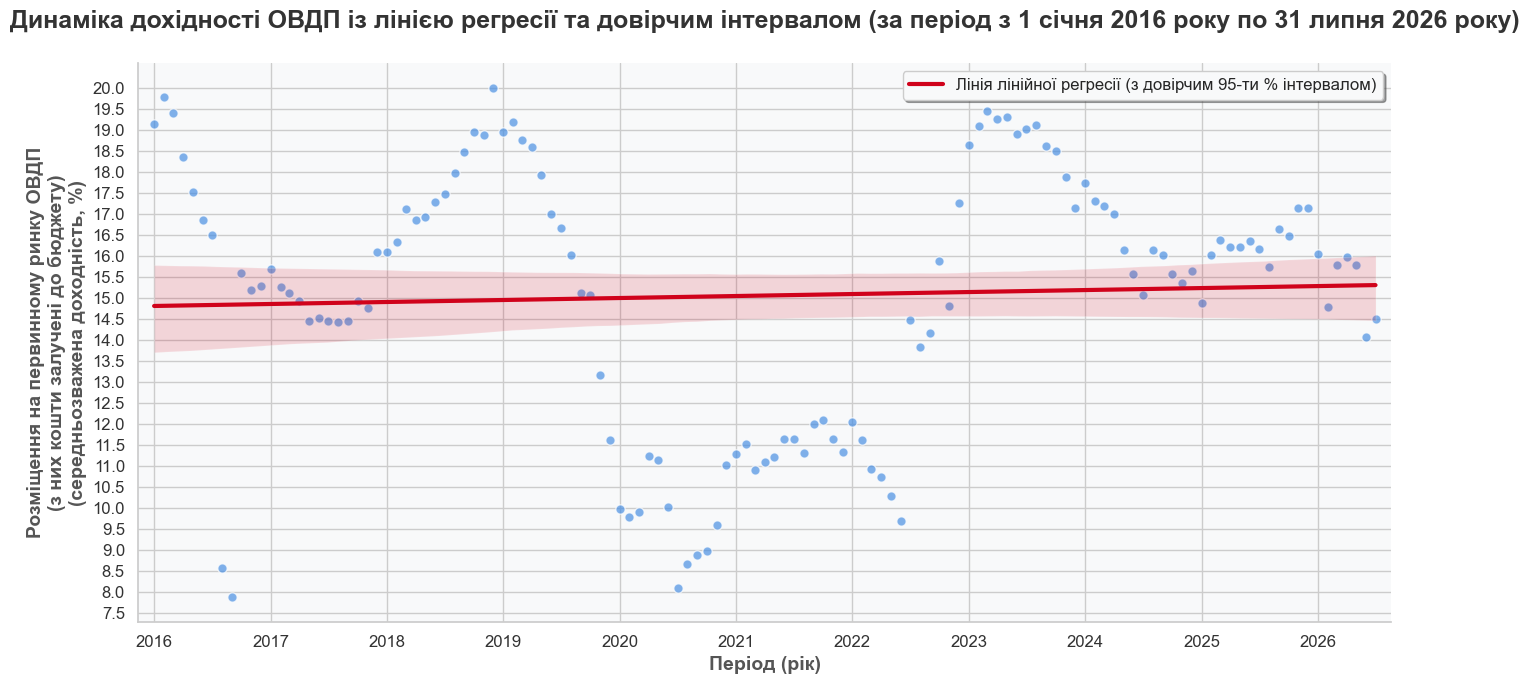

In [45]:
fix, ax = plt.subplots(figsize = (14, 7))
sns.regplot(
    data = df_selected,
    x = 'Ordinal Date',
    y = 'Yield',
    ax = ax,
    scatter_kws = {
        "color": "#4A90E2",
        "alpha": 0.7,
        "s": 45,
        "edgecolor": "w"
    },
    line_kws = {
        "color": "#D0021B",
        "linewidth": 3,
        "label": "Лінія лінійної регресії (з довірчим 95-ти % інтервалом)"
    }
)
ax.set_xlim(df_selected['Ordinal Date'].min() - 50, df_selected['Ordinal Date'].max() + 50)
ax.set_xticks(df_selected['Ordinal Date'][::12])
custom_labels = [pd.Timestamp.fromordinal(int(date)).strftime('%Y') for date in ax.get_xticks()]
ax.set_xticklabels(custom_labels)
ax.set_title(
    'Динаміка дохідності ОВДП із лінією регресії та довірчим інтервалом (за період з 1 січня 2016 року по 31 липня 2026 року)\n',
    fontsize = 18,
    fontweight = 'bold',
    color = '#333333'
)
ax.set_xlabel(
    'Період (рік)', 
    fontsize = 14, 
    fontweight = 'bold', 
    color = '#555555'
)
ax.set_ylabel(
    'Розміщення на первинному ринку ОВДП\n(з них кошти залучені до бюджету)\n(середньозважена доходність, %)',
    fontsize = 14,
    fontweight = 'bold',
    color = '#555555'
)
plt.xticks(
    fontsize = 12,
    color = '#333333',
    rotation = 0
)
plt.yticks(
    np.arange(7.5, 20.5, 0.5),
    fontsize = 12,
    color = '#333333'
)
ax.legend(
    loc = 'upper right',
    fontsize = 12,
    frameon = True,
    shadow= True
)
sns.despine()
plt.tight_layout()
plt.savefig(
    'Динаміка дохідності ОВДП із лінією регресії та довірчим інтервалом (за період з 1 січня 2016 року по 31 липня 2026 року).png',
    dpi = 300
)
plt.show()

In [13]:
df_selected = df_selected.dropna(subset = ['Date', 'Yield']).sort_values(by = "Date").reset_index(drop = True)

In [14]:
df_selected['Month Index'] = np.arange(len(df_selected))

In [15]:
X = df_selected['Month Index']
X = sm.add_constant(X)
y = df_selected['Yield']

In [16]:
ols_model = sm.OLS(y, X).fit()

In [17]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Yield   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.2781
Date:                Sun, 16 Aug 2026   Prob (F-statistic):              0.599
Time:                        15:46:33   Log-Likelihood:                -322.88
No. Observations:                 127   AIC:                             649.8
Df Residuals:                     125   BIC:                             655.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          14.8165      0.547     27.092      

In [18]:
df_selected = df_selected.dropna(subset = ['Date', 'Yield']).sort_values(by = "Date").reset_index(drop = True)

In [19]:
y = df_selected['Yield']

In [20]:
def augmented_dickey_fuller_test(series, name):
    result = adfuller(series.dropna())
    print(f"Augmented Dickey-Fuller Statistics: {result[0]:.4f}")
    print(f"P-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f" {key}: {value:.4f}")
    print(f"Is stationary (p < 0.05) ? {result[1] < 0.05}\n")

In [21]:
augmented_dickey_fuller_test(y, "Оригінальний часовий ряд (d = 0)")

Augmented Dickey-Fuller Statistics: -2.5663
P-value: 0.1002
Critical Values:
 1%: -3.4833
 5%: -2.8848
 10%: -2.5792
Is stationary (p < 0.05) ? False



In [22]:
augmented_dickey_fuller_test(y.diff().dropna(), "Перша різниця (d = 1)")

Augmented Dickey-Fuller Statistics: -10.9154
P-value: 0.0000
Critical Values:
 1%: -3.4838
 5%: -2.8850
 10%: -2.5793
Is stationary (p < 0.05) ? True



In [23]:
df_selected = df_selected.dropna(subset = ['Date', 'Yield']).sort_values(by = "Date").reset_index(drop = True)

In [24]:
y_diff = df_selected['Yield'].diff().dropna()

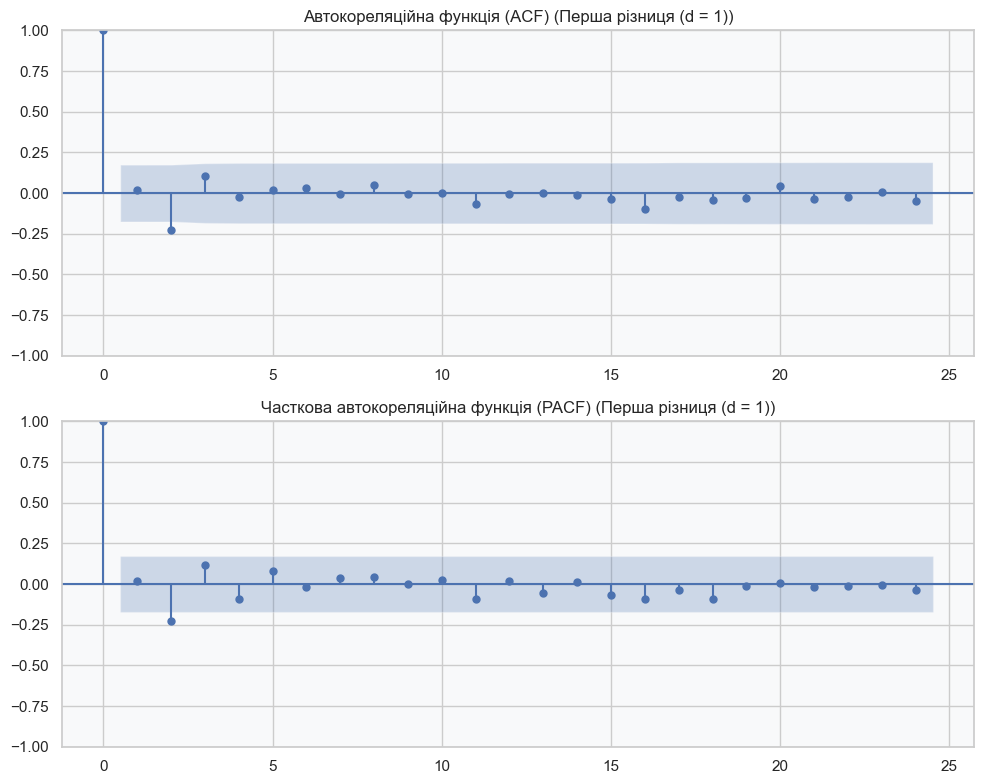

In [32]:
fig, ax = plt.subplots(2, 1, figsize = (10, 8))
plot_acf(y_diff, ax = ax[0], lags = 24, title = 'Автокореляційна функція (ACF) (Перша різниця (d = 1))')
plot_pacf(y_diff, ax = ax[1], lags = 24, title = 'Часткова автокореляційна функція (PACF) (Перша різниця (d = 1))')
plt.tight_layout()
plt.savefig(
    'Автокореляційна функція (ACF) та Часткова автокореляційна функція (PACF) (Перша різниця (d = 1)).png',
    dpi = 300
)
plt.show()

In [33]:
df_selected = df_selected.dropna(subset = ['Date', 'Yield']).sort_values(by = "Date").reset_index(drop = True)

In [40]:
p_values = range(0, 4)
d_values = [1]
q_values = range(0, 4)
best_aic = float("inf")
best_order = None
best_model = None

for p, d, q in product(p_values, d_values, q_values):
    try:
        arima_model = sm.tsa.ARIMA(y, order = (p, d, q))
        results = arima_model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
            best_model = results
    except Exception as e:
        continue
        
print(f"Best ARIMA order: {best_order} with AIC: {best_aic:.2f}")
print(best_model.summary())

D:\Programmes\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Programmes\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Best ARIMA order: (0, 1, 2) with AIC: 418.48
                               SARIMAX Results                                
Dep. Variable:                  Yield   No. Observations:                  127
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -206.239
Date:                Sun, 16 Aug 2026   AIC                            418.477
Time:                        16:12:44   BIC                            426.986
Sample:                             0   HQIC                           421.934
                                - 127                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1012      0.126      0.800      0.424      -0.147       0.349
ma.L2         -0.2718      0.033     -8.122      0.000      -0.337      -0.206
sigma2 

In [41]:
best_aic_s = float("inf")
best_order_s = None
best_s_order = None
best_model_s = None

for p, q in product(range(0, 3), range(0, 3)):
    for P, Q in product(range(0, 2), range(0, 2)):
        try:
            arima_model = sm.tsa.ARIMA(y, order = (p, 1, q), seasonal_order = (P, 0, Q, 12))
            results = arima_model.fit()
            if results.aic < best_aic_s:
                best_aic_s = results.aic
                best_order_s = (p, 1, q)
                best_s_order = (P, 0, Q, 12)
                best_model_s = results
        except Exception as e:
            continue
print(f"Best SARIMA order: {best_order_s} x {best_s_order} with AIC: {best_aic_s:.2f}")
print(best_model_s.summary())

Best SARIMA order: (0, 1, 2) x (0, 0, 0, 12) with AIC: 418.48
                               SARIMAX Results                                
Dep. Variable:                  Yield   No. Observations:                  127
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -206.239
Date:                Sun, 16 Aug 2026   AIC                            418.477
Time:                        16:19:41   BIC                            426.986
Sample:                             0   HQIC                           421.934
                                - 127                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1012      0.126      0.800      0.424      -0.147       0.349
ma.L2         -0.2718      0.033     -8.122      0.000      -0.337   

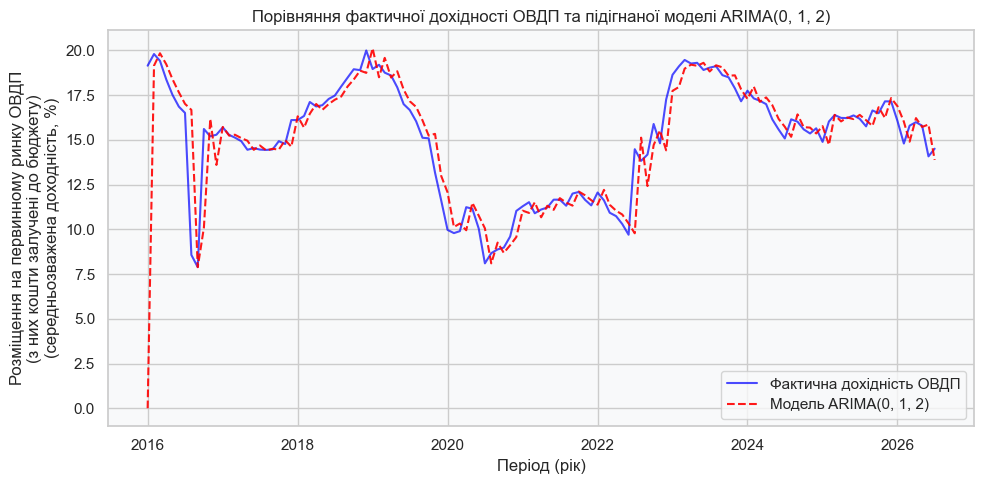

In [43]:
arima_model = sm.tsa.ARIMA(y, order = (0, 1, 2))
results = arima_model.fit()

fix, ax = plt.subplots(figsize = (10, 5))
ax.plot(df_selected['Date'], y, label = 'Фактична дохідність ОВДП', color = 'blue', alpha = 0.7)
ax.plot(df_selected['Date'], results.fittedvalues, label = 'Модель ARIMA(0, 1, 2)', color = 'red', linestyle = '--', alpha = 0.9)
ax.set_title('Порівняння фактичної дохідності ОВДП та підігнаної моделі ARIMA(0, 1, 2)')
ax.set_xlabel('Період (рік)')
ax.set_ylabel('Розміщення на первинному ринку ОВДП\n(з них кошти залучені до бюджету)\n(середньозважена доходність, %)')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    'Порівняння фактичної дохідності ОВДП та підігнаної моделі ARIMA(0, 1, 2)',
    dpi = 300
)
plt.show()

In [100]:
df_selected = df_selected.dropna(subset = ['Date', 'Yield']).sort_values(by = 'Date').reset_index(drop = True)

In [101]:
y = df_selected['Yield']
dates = df_selected['Date']

In [102]:
best_aic = float("inf")
best_order = None
best_seasonal = None
best_model = None

In [103]:
for p, q in product(range(0, 3), range(0, 3)):
    for P, D, Q in product(range(0, 2), [0, 1], range(0, 2)):
        if P + D + Q == 0:
            continue
        try:
            model = sm.tsa.SARIMAX(y, order = (p, 1, q), seasonal_order = (P, D, Q, 12))
            results = model.fit(disp = False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p, 1, q)
                best_seasonal = (P, D, Q, 12)
                best_model = results
        except Exception:
            continue
print(f"Найкраща модель, що була знайдена: SARIMA {best_order} x {best_seasonal} (AIC: {best_aic:.2f})")

Найкраща модель, що була знайдена: SARIMA (0, 1, 2) x (0, 1, 1, 12) (AIC: 405.17)


In [104]:
forecast_steps = 24
forecast_obj = best_model.get_forecast(steps = forecast_steps)
forecast_mean = forecast_obj.predicted_mean
confidence_interval = forecast_obj.conf_int(alpha = 0.05)

In [105]:
holt_winters_model = ExponentialSmoothing(
    y,
    trend = 'add',
    seasonal = 'add',
    seasonal_periods = 12,
    initialization_method = 'estimated'
)
holt_winters_results = holt_winters_model.fit()
holt_winters_forecast = holt_winters_results.forecast(steps = forecast_steps)
print(f"Модель Хольта-Вінтерса (AIC: {holt_winters_results.aic:.2f})")

Модель Хольта-Вінтерса (AIC: 80.49)


In [106]:
prophet_df = pd.DataFrame({ 'ds': dates, 'y': y })
prophet_model = Prophet(
    seasonality_mode = 'additive',
    yearly_seasonality = True,
    weekly_seasonality = True,
    daily_seasonality = True
)
prophet_model.fit(prophet_df)
future_prophet_df = prophet_model.make_future_dataframe(periods = forecast_steps, freq = 'ME')
prophet_forecast = prophet_model.predict(future_prophet_df)
prophet_future_forecast_only = prophet_forecast.tail(forecast_steps)

00:52:47 - cmdstanpy - INFO - Chain [1] start processing
00:52:49 - cmdstanpy - INFO - Chain [1] done processing


In [107]:
machine_learning_df = pd.DataFrame({
    'Yeild': y,
    'Trend Index': np.arange(len(y)),
    'Month': dates.dt.month
})

In [108]:
X_train = machine_learning_df[['Trend Index', 'Month']]
y_train = machine_learning_df[['Yeild']]

In [109]:
last_date = dates.iloc[-1]
future_dates = pd.date_range(
    start = last_date + pd.DateOffset(months = 1), 
    periods = forecast_steps, 
    freq = 'ME'
)

In [111]:
X_future = pd.DataFrame({
    'Trend Index': np.arange(len(y), len(y) + forecast_steps),
    'Month': future_dates.month
})

In [115]:
random_forest_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
random_forest_model.fit(X_train, y_train)
random_forest_forecast = random_forest_model.predict(X_future)

In [116]:
xgboots_model = XGBRegressor(n_estimators = 100, learning_rage = 0.1, random_state = 42)
xgboots_model.fit(X_train, y_train)
xgboots_model_forecast = xgboots_model.predict(X_future)

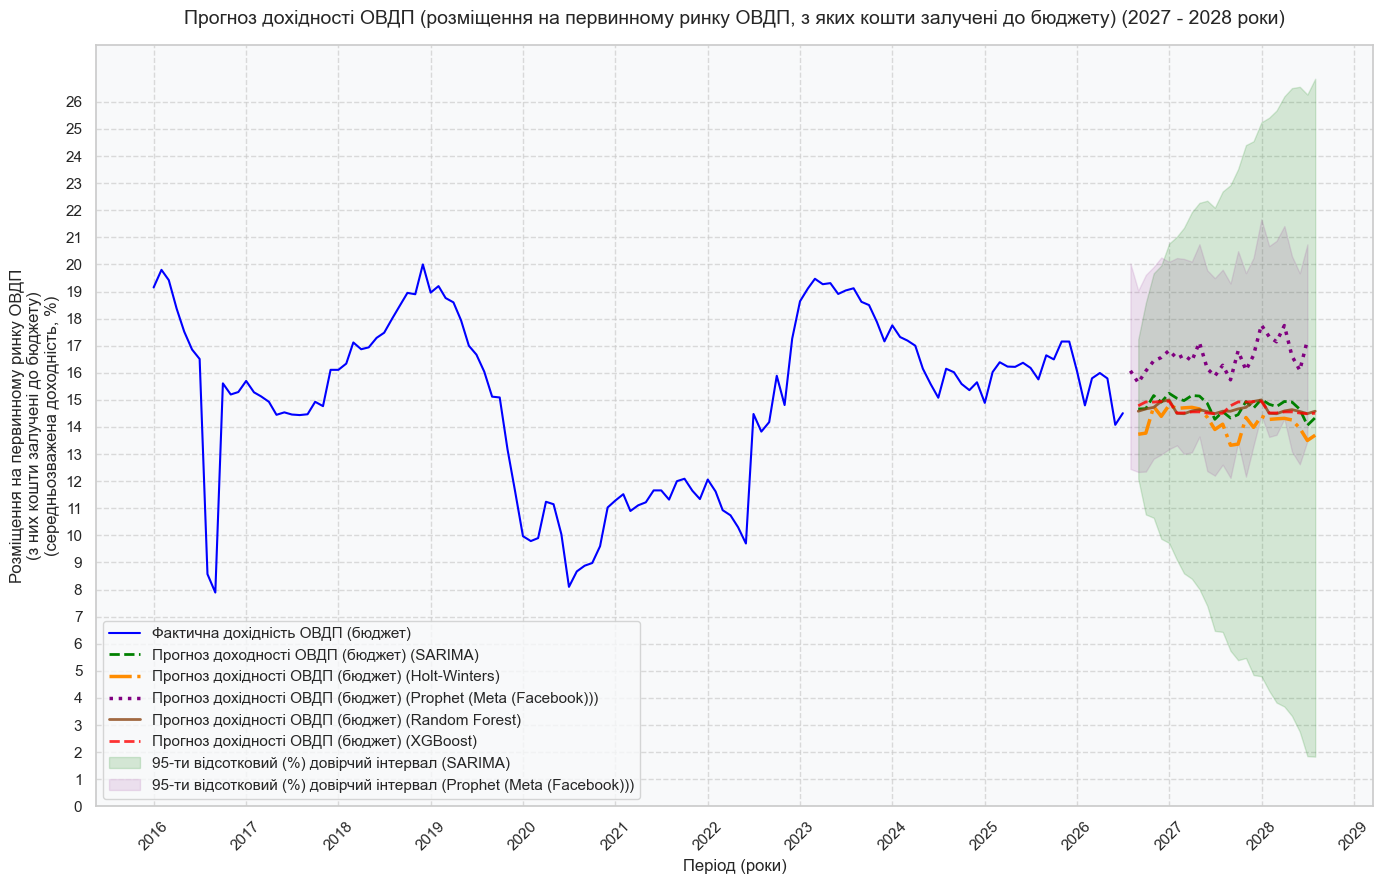

In [122]:
fig, ax = plt.subplots(figsize = (14, 9))
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.plot(
    dates, 
    y, 
    label = 'Фактична дохідність ОВДП (бюджет)', 
    color = 'blue', 
    linewidth = 1.5
)
ax.plot(
    future_dates, 
    forecast_mean, 
    label = 'Прогноз доходності ОВДП (бюджет) (SARIMA)',
    color = 'green', 
    linestyle = '--', 
    linewidth = 2
)
ax.plot(
    future_dates,
    holt_winters_forecast,
    label = 'Прогноз дохідності ОВДП (бюджет) (Holt-Winters)',
    color = 'darkorange',
    linestyle = '-.',
    linewidth = 2.5
)
ax.plot(
    prophet_future_forecast_only['ds'],
    prophet_future_forecast_only['yhat'],
    label = 'Прогноз дохідності ОВДП (бюджет) (Prophet (Meta (Facebook)))',
    color = 'purple',
    linestyle = ':',
    linewidth = 2.5
)
ax.plot(
    future_dates,
    random_forest_forecast,
    label = 'Прогноз дохідності ОВДП (бюджет) (Random Forest)',
    color = 'saddlebrown',
    linestyle = '-',
    linewidth = 2,
    alpha = 0.8
)
ax.plot(
    future_dates,
    xgboots_model_forecast,
    label = 'Прогноз дохідності ОВДП (бюджет) (XGBoost)',
    color = 'red',
    linestyle = '--',
    linewidth = 2,
    alpha = 0.8
)
ax.fill_between(
    future_dates, 
    confidence_interval.iloc[:, 0], 
    confidence_interval.iloc[:, 1], 
    color = 'green', 
    alpha = 0.15, 
    label = '95-ти відсотковий (%) довірчий інтервал (SARIMA)'
)
ax.fill_between(
    prophet_future_forecast_only['ds'], 
    prophet_future_forecast_only['yhat_lower'], 
    prophet_future_forecast_only['yhat_upper'], 
    color = 'purple', 
    alpha = 0.1, 
    label = '95-ти відсотковий (%) довірчий інтервал (Prophet (Meta (Facebook)))'
)
ax.set_title(
    f'Прогноз дохідності ОВДП (розміщення на первинному ринку ОВДП, з яких кошти залучені до бюджету) (2027 - 2028 роки)', 
    fontsize = 14, 
    pad = 15
)
ax.set_xlabel('Період (роки)', fontsize = 12)
ax.set_ylabel(
    'Розміщення на первинному ринку ОВДП\n(з них кошти залучені до бюджету)\n(середньозважена доходність, %)', 
    fontsize = 12
)
ax.legend(loc = 'lower left', fontsize = 11)
ax.grid(True, linestyle = '--', alpha = 0.7)
plt.xticks(rotation = 45)
plt.yticks(np.arange(0, 27, 1), fontsize = 11)
plt.tight_layout()
plt.show()